In [ ]:
using Plots,LinearAlgebra,LaTeXStrings
import BifurcationKit as BK
import BifurcationKit: @optic

const 𝒥    = 1.0
const 𝒦    = 1.0
const ρmax = 𝒦

function TMvf(z, p)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p
	N, exC, μ = z
    Cs = 10^exC
    [
        r*N*(1 - N/ρmax) - δN*(1-μ)*Cs*N,
        σ0 + σ1*N + rC*Cs*N - βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,
        (ΩT*N/𝒥 + Ω/𝒥)*(1-μ) - βr*μ*N*(1-μ) - βδ*μ*(1-μ) - (μ/Cs)*(σ0 + σ1*N)
    ]
end

function Jac(u, par)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = par
    J = zeros(eltype(u), 3, 3)

    N, exC, μC = u
    Cs = 10^exC # definition of Cs here is missing
    T=diagm([1,log(10)*Cs,1]) # matrix that trasform the variables
    J[1,1] = r - 2*r*N/ρmax - δN*(1 - μC)*Cs
    J[1,2] = -δN*(1 - μC)*N
    J[1,3] =  δN*N*Cs
    J[2,1] = σ1 + rC*Cs - βr*Cs*μC
    J[2,2] = rC*N - βr*μC*N - βδ*μC - δC
    J[2,3] = -βr*Cs*N - βδ*Cs
    J[3,1] = (ΩT/𝒥)*(1 - μC) - βr*μC*(1 - μC) - (μC/Cs)*σ1
    J[3,2] =  (μC/Cs^2)*(σ0 + σ1*N)
    J[3,3] = -ΩT*N/𝒥 - Ω/𝒥 - (βr*N + βδ)*(1 - 2*μC) - (σ0 + σ1*N)/Cs
    return J*T
end

par_tm = (
    r   = 0.08078290935711611,
    #rC  = 0.14,
    rC  = 0.14,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    #ΩT  = 1.0,
    ΩT  = 0.021848896684677162,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    #σ0  = 0.86,
    σ0  = 1.5,
    σ1  = 0.8626645475366396
)

function coex_quadratic_coeffs(par)
    (; rC, δC, δN, Ω, ΩT, σ0, σ1, r) = par
    A = rC - ΩT/𝒥
    B = (ΩT*𝒦)/𝒥 - rC*𝒦 - Ω/𝒥 - δC - δN*σ1/r
    C_coef = (Ω*𝒦)/𝒥 + δC*𝒦 - δN*σ0/r
    return A, B, C_coef
end

function coex_C_muC(N, par)
    (; Ω, ΩT, βr, βδ, δC, rC, σ0, σ1) = par
    ΩoJ  = Ω/𝒥
    ΩToJ = ΩT/𝒥
    denom_mu = max(ΩToJ*N + ΩoJ + βr*N + βδ + δC - rC*N, 1e-14)
    μC = clamp((ΩToJ*N + ΩoJ) / denom_mu, 0.0, 1.0)
    denom_C = (βr*N + βδ + δC - rC*N) * μC
    denom_C = abs(denom_C) < 1e-14 ? 1e-14 : denom_C
    C = (σ0 + σ1*N) / denom_C
    return C, μC
end

function coex_roots(par)
    A, B, C_coef = coex_quadratic_coeffs(par)
    roots = Float64[]
    if abs(A) < 1e-12
        abs(B) < 1e-12 && return roots
        N_cand = -C_coef / B
        N_cand > 0 || return roots
        C_cand, μC_cand = coex_C_muC(N_cand, par)
        C_cand > 0 && 0 < μC_cand < 1 && push!(roots, N_cand)
        return roots
    end
    disc = B^2 - 4*A*C_coef
    disc < 0 && return roots
    for s in (+1, -1)
        N_cand = (-B + s*sqrt(disc)) / (2*A)
        N_cand > 1e-8 || continue
        C_cand, μC_cand = coex_C_muC(N_cand, par)
        C_cand > 0 || continue
        0 < μC_cand < 1 || continue
        N_cand < 2 || continue
        push!(roots, N_cand)
    end
    return roots
end


N0 = 0.0
C0, μ0 = coex_C_muC(N0, par_tm)
x0 = [N0, log10(C0), μ0]
prob = BK.ODEBifProblem(TMvf, x0, par_tm, (@optic _.σ0);
    J=Jac,
    record_from_solution = (x, p; k...) -> (N = x[1], C = 10^x[2], μ = x[3]))

opts_br = BK.ContinuationPar(p_min = 0.01, p_max = 2.0,
    ds = 0.01, dsmax = 0.05, max_steps = 500,
    detect_bifurcation = 3, n_inversion = 6)

br = BK.continuation(prob, BK.PALC(),opts_br; bothside = true)
Ns = coex_roots(par_tm)
N0 =Ns[1]
C0, μ0 = coex_C_muC(N0, par_tm)
x0 = [N0, log10(C0), μ0]
brA =BK.continuation(BK.re_make(prob,u0=x0),BK.PALC(),opts_br; bothside = true)

 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 38
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter σ0 starts at 0.01, ends at 2.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at σ0 ≈ +0.01000000,                                                                     step =   0
- #  2,       bp at σ0 ≈ +1.68192714 ∈ (+1.68179108, +1.68192714), |δp|=1e-04, [converged], δ = ( 1,  0), step =  32
- #  3, endpoint at σ0 ≈ +2.00000000,                                                                     step =  37


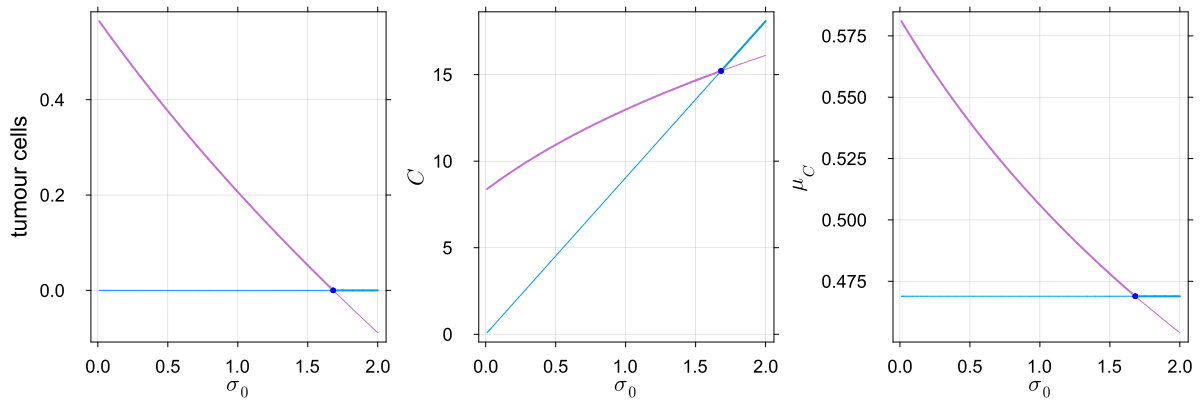

In [ ]:
default(fontfamily="Arial",framestyle=:box, label=nothing, grid=true,tickfont = font(12, "Arial"),guidefont=font(15,"Arial"),tick_direction=:out)
gr()
p=plot(layout=(1,3),size=(1200,400))
plot!(p,subplot=1,br,vars=(:param,:N))
plot!(p,subplot=1,brA,vars=(:param,:N), legend = false,ylabel="tumour cells",left_margin=8Plots.mm,right_margin=2Plots.mm,bottom_margin=6Plots.mm,xlabel=L"$\sigma_0$",yticks=([-0.2,0,0.2,0.6,0.4,0.8]))
plot!(p,subplot=2,br,vars=(:param,:C),)
plot!(p,subplot=2,brA,vars=(:param,:C), ylabel=L"$C$", legend = false,left_margin=6Plots.mm,right_margin=2Plots.mm,xlabel=L"$\sigma_0$")
plot!(p,subplot=3,br,vars=(:param,:μ),)
plot!(p,subplot=3,brA,vars=(:param,:μ), ylabel=L"$\mu_C$", legend = false,left_margin=6Plots.mm,xlabel=L"$\sigma_0$")

In [ ]:
par_tm = (
    r   = 0.08078290935711611,
    #rC  = 0.14,
    rC  = 0.14,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    #ΩT  = 0.021848896684677162,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    #σ0  = 0.86,
    σ0  = 0.8,
    σ1  = 0.8626645475366396
)
Ns = coex_roots(par_tm)
@assert !isempty(Ns) "no coexistence equilibrium at initial σ0"
N0 = Ns[1]
C0, μ0 = coex_C_muC(N0, par_tm)
x0 = [N0, log10(C0), μ0]
prob = BK.ODEBifProblem(TMvf, x0, par_tm, (@optic _.σ0);
    J=Jac,
    record_from_solution = (x, p; k...) -> (N = x[1], C = 10^x[2], μ = x[3]))
opt_new=BK.NewtonPar(tol = 1e-8, max_iterations = 5,verbose=true)

sol_x0 = @time BK.solve(prob, BK.Newton(), opt_new)

opts_br = BK.ContinuationPar(p_min = 0.0, p_max = 4.0,
    ds = 0.005, dsmax = 0.05, max_steps = 800,newton_options = BK.setproperties(opt_new;max_iterations=5,verbose=false),
    detect_bifurcation = 3, n_inversion = 6)
br2 = BK.continuation(BK.re_make(prob,u0=sol_x0.u), BK.PALC(), opts_br;bothside=true)


C0, μ0 = coex_C_muC(0.0, par_tm)
x0 = [0.0, log10(C0), μ0]
br2A = BK.continuation(BK.re_make(prob,u0=x0), BK.PALC(), opts_br;bothside=true)



┌─────────────────────────────────────────────────────┐
│ Newton step         residual      linear iterations │
├─────────────┬──────────────────────┬────────────────┤
│       0     │       1.3199e-01     │        0       │
│       1     │       6.7941e-03     │        1       │
│       2     │       2.3676e-05     │        1       │
│       3     │       8.6134e-11     │        1       │
└─────────────┴──────────────────────┴────────────────┘
  0.100457 seconds (261.88 k allocations: 13.631 MiB, 99.48% compilation time)


 ┌─ Curve type: EquilibriumCont
 ├─ Number of points: 856
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter σ0 starts at 3.538045400791922e-97, ends at 4.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at σ0 ≈ +0.00000000,                                                                     step =  -1
- #  2,       bp at σ0 ≈ +1.68188797 ∈ (+1.68187090, +1.68188797), |δp|=2e-05, [converged], δ = (-1,  0), step = 822
- #  3, endpoint at σ0 ≈ +4.00000000,                                                                     step = 855


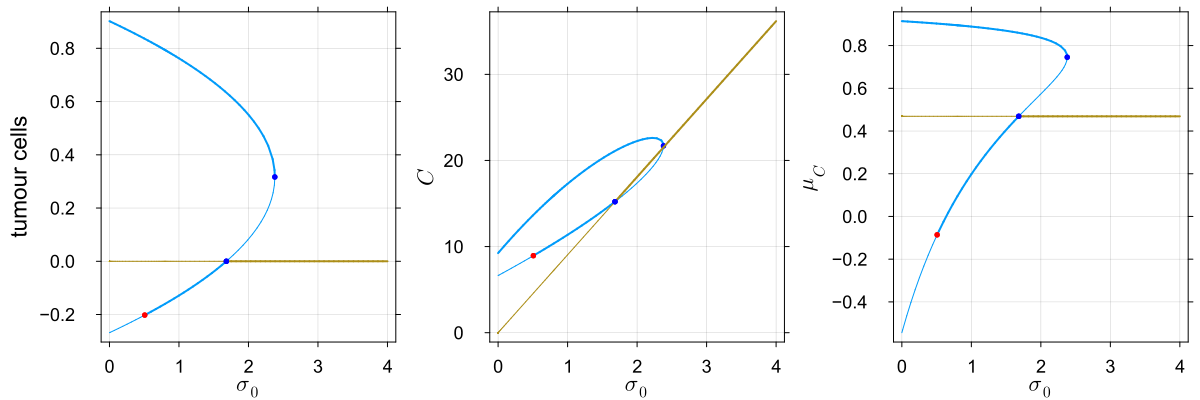

In [ ]:
default(fontfamily="Arial",framestyle=:box, label=nothing, grid=true,tickfont = font(12, "Arial"),guidefont=font(15,"Arial"),tick_direction=:out)
gr()
p=plot(layout=(1,3),size=(1200,400))
plot!(p,subplot=1,br2,vars=(:param,:N))
plot!(p,subplot=1,br2A,vars=(:param,:N), legend = false,ylabel="tumour cells",left_margin=8Plots.mm,right_margin=2Plots.mm,bottom_margin=6Plots.mm,xlabel=L"$\sigma_0$",yticks=([-0.2,0,0.2,0.6,0.4,0.8]))
plot!(p,subplot=2,br2,vars=(:param,:C),)
plot!(p,subplot=2,br2A,vars=(:param,:C), ylabel=L"$C$", legend = false,left_margin=6Plots.mm,right_margin=2Plots.mm,xlabel=L"$\sigma_0$")
plot!(p,subplot=3,br2,vars=(:param,:μ),)
plot!(p,subplot=3,br2A,vars=(:param,:μ), ylabel=L"$\mu_C$", legend = false,left_margin=6Plots.mm,xlabel=L"$\sigma_0$")

In [ ]:

par_tm = (
    r   = 0.08078290935711611,
    #rC  = 0.14,
    rC  = 0.75,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    #ΩT  = 0.021848896684677162,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    #σ0  = 0.86,
    σ0  = 0.8,
    σ1  = 0.8626645475366396
)

N0 = 0.0
C0, μ0 = coex_C_muC(N0, par_tm)
x0 = [N0, log10(C0), μ0]
prob = BK.ODEBifProblem(TMvf, x0, par_tm, (@optic _.σ0);
    J=Jac,
    record_from_solution = (x, p; k...) -> (N = x[1], C = x[2], μ = x[3]))
opt_new=BK.NewtonPar(tol = 1e-8, max_iterations = 5,verbose=true)

sol_x0 = @time BK.solve(prob, BK.Newton(), opt_new)

opts_br = BK.ContinuationPar(p_min = 0.0, p_max = 4.0,
    ds = 0.005, dsmax = 0.05, max_steps = 800,newton_options = BK.setproperties(opt_new;max_iterations=5,verbose=false),
    detect_bifurcation = 3, n_inversion = 6)
br3 = BK.continuation(BK.re_make(prob,u0=sol_x0.u), BK.PALC(), opts_br;bothside=true)
br3A= BK.continuation(br3,2, opts_br;bothside=true)



┌─────────────────────────────────────────────────────┐
│ Newton step         residual      linear iterations │
├─────────────┬──────────────────────┬────────────────┤
│       0     │       1.0631e-01     │        0       │
│       1     │       5.9874e-03     │        1       │
│       2     │       1.8045e-05     │        1       │
│       3     │       2.0309e-10     │        1       │
└─────────────┴──────────────────────┴────────────────┘
  0.022570 seconds (43.11 k allocations: 2.282 MiB, 98.63% compilation time)


┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/Bifurcations.jl:210
┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/Bifurcations.jl:210
┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/Bifurcations.jl:210
┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/Bifurcations.jl:210
┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/Bifurcations.jl:210
┌ Error: Failure to converge with given tolerance = 1.0e-8.
│ Step = 92
│ You can decrease the tolerance or pa

 ┌─ Curve type: EquilibriumCont from Transcritical bifurcation point.
 ├─ Number of points: 181
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter σ0 starts at 1.366665887615465, ends at 0.0
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at σ0 ≈ +1.36666589,                                                                     step =   0
- #  2,       bp at σ0 ≈ +1.36666589 ∈ (+1.36666589, +1.36666589), |δp|=1e-12, [    guess], δ = (-1,  0), step =   0
- #  3,       bp at σ0 ≈ +1.36666589 ∈ (+1.36666589, +1.36666589), |δp|=3e-12, [    guess], δ = ( 1,  0), step =   3
- #  4,       bp at σ0 ≈ +1.36666589 ∈ (+1.36666589, +1.36666589), |δp|=2e-12, [    guess], δ = (-1,  0), step =   4
- #  5,       bp at σ0 ≈ +1.36666589 ∈ (+1.36666589, +1.36666589), |δp|=2e-12, [   guessL], δ = ( 1,  0), step =   5
- #  6,       bp at σ0 ≈ +1.36666589 ∈ (+1.36666589, +1.36666589), |δp|=5e-11, [    guess], δ = (-1,  0), step =   6
- #  7,       bp at σ0 ≈ +1.68186797 ∈ (+1.68186797, +1.681876

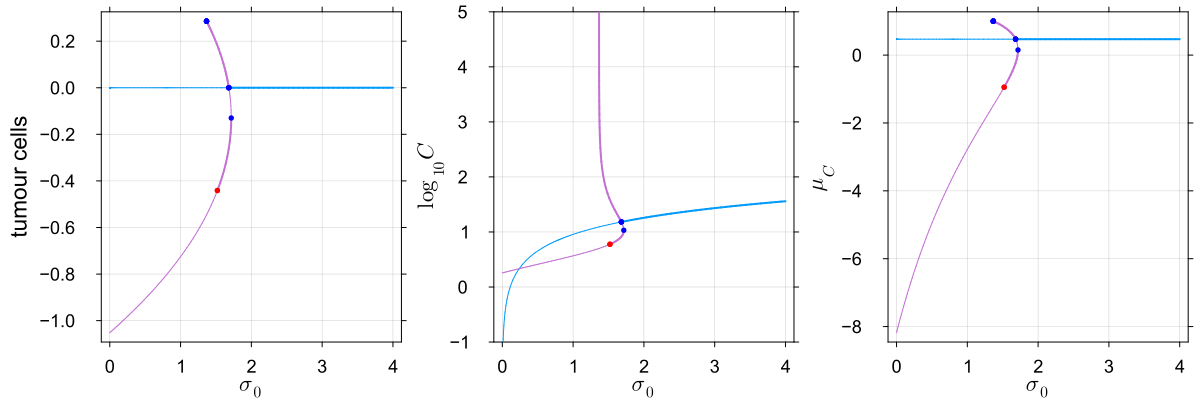

In [ ]:
default(fontfamily="Arial",framestyle=:box, label=nothing, grid=true,tickfont = font(12, "Arial"),guidefont=font(15,"Arial"),tick_direction=:out)
gr()
p=plot(layout=(1,3),size=(1200,400))
plot!(p,subplot=1,br3,vars=(:param,:N))
plot!(p,subplot=1,br3A,vars=(:param,:N), legend = false,ylabel="tumour cells",left_margin=8Plots.mm,right_margin=2Plots.mm,bottom_margin=6Plots.mm,xlabel=L"$\sigma_0$")
plot!(p,subplot=2,br3,vars=(:param,:C),)
plot!(p,subplot=2,br3A,vars=(:param,:C), ylabel=L"$\log_{10}C$", legend = false,left_margin=6Plots.mm,right_margin=2Plots.mm,xlabel=L"$\sigma_0$",ylim=(-1,5))
plot!(p,subplot=3,br3,vars=(:param,:μ),)
plot!(p,subplot=3,br3A,vars=(:param,:μ), ylabel=L"$\mu_C$", legend = false,left_margin=6Plots.mm,xlabel=L"$\sigma_0$")

In [ ]:
par_tm = BK.setproperties(par_tm; rC=0.3)

N0 = 0.0
C0, μ0 = coex_C_muC(N0, par_tm)
x0 = [N0, log10(C0), μ0]
prob = BK.ODEBifProblem(TMvf, x0, par_tm, (@optic _.σ0);
    J=Jac,
    record_from_solution = (x, p; k...) -> (N = x[1], C = x[2], μ = x[3]))
opt_new=BK.NewtonPar(tol = 1e-8, max_iterations = 5,verbose=true)

sol_x0 = @time BK.solve(prob, BK.Newton(), opt_new)

opts_br = BK.ContinuationPar(p_min = 0.0, p_max = 4.0,
    ds = 0.005, dsmax = 0.05, max_steps = 800,newton_options = BK.setproperties(opt_new;max_iterations=5,verbose=false),
    detect_bifurcation = 3, n_inversion = 6)
br4 = BK.continuation(BK.re_make(prob,u0=sol_x0.u), BK.PALC(), opts_br;bothside=true)
br4A= BK.continuation(br4,2, opts_br;bothside=true)


┌─────────────────────────────────────────────────────┐
│ Newton step         residual      linear iterations │
├─────────────┬──────────────────────┬────────────────┤
│       0     │       1.0631e-01     │        0       │
│       1     │       5.9874e-03     │        1       │
│       2     │       1.8045e-05     │        1       │
│       3     │       2.0309e-10     │        1       │
└─────────────┴──────────────────────┴────────────────┘
  0.022615 seconds (43.11 k allocations: 2.291 MiB, 98.79% compilation time)


┌ Error: Failure to converge with given tolerance = 1.0e-8.
│ Step = 100
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 0.0001.
│ Stopping continuation at continuation step 100.
└ @ BifurcationKit /Users/negar/.julia/packages/BifurcationKit/NgNA0/src/continuation/Contbase.jl:73


 ┌─ Curve type: EquilibriumCont from Transcritical bifurcation point.
 ├─ Number of points: 138
 ├─ Type of vectors: Vector{Float64}
 ├─ Parameter σ0 starts at 0.0, ends at 0.8417811133456631
 ├─ Algo: PALC [Secant]
 └─ Special points:

- #  1, endpoint at σ0 ≈ +0.00000000,                                                                     step =   0
- #  2,     hopf at σ0 ≈ +0.65241816 ∈ (+0.65241816, +0.65247867), |δp|=6e-05, [converged], δ = (-2, -2), step =  12
- #  3,       bp at σ0 ≈ +1.68187180 ∈ (+1.68187180, +1.68187369), |δp|=2e-06, [converged], δ = ( 1,  0), step =  35
- #  4,       bp at σ0 ≈ +1.68187269 ∈ (+1.68187267, +1.68187269), |δp|=1e-08, [converged], δ = ( 1,  0), step =  38
- #  5,       bp at σ0 ≈ +2.10955142 ∈ (+2.10955142, +2.10955142), |δp|=6e-10, [converged], δ = (-1,  0), step =  53
- #  6, endpoint at σ0 ≈ +0.84178111,                                                                     step = 137


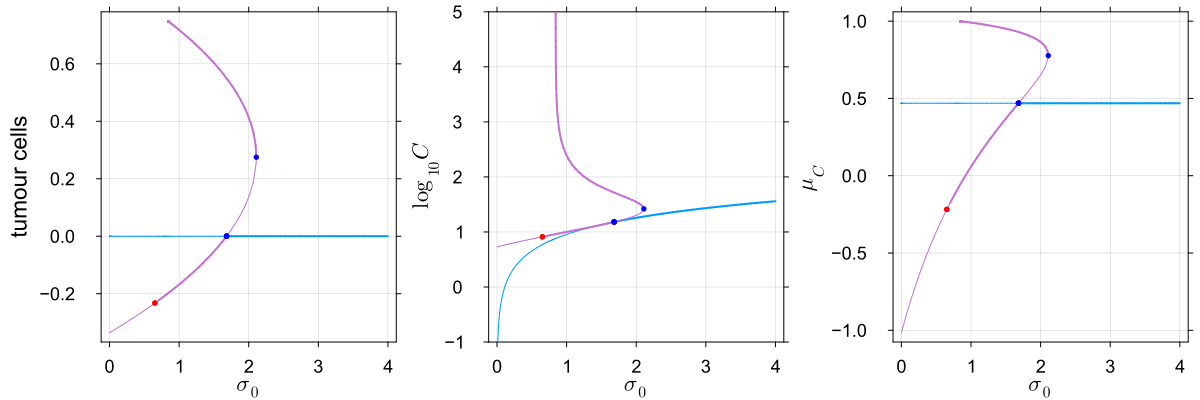

In [ ]:
default(fontfamily="Arial",framestyle=:box, label=nothing, grid=true,tickfont = font(12, "Arial"),guidefont=font(15,"Arial"),tick_direction=:out)
gr()
p=plot(layout=(1,3),size=(1200,400))
plot!(p,subplot=1,br4,vars=(:param,:N))
plot!(p,subplot=1,br4A,vars=(:param,:N), legend = false,ylabel="tumour cells",left_margin=8Plots.mm,right_margin=2Plots.mm,bottom_margin=6Plots.mm,xlabel=L"$\sigma_0$")
plot!(p,subplot=2,br4,vars=(:param,:C),)
plot!(p,subplot=2,br4A,vars=(:param,:C), ylabel=L"$\log_{10}C$", legend = false,left_margin=6Plots.mm,right_margin=2Plots.mm,xlabel=L"$\sigma_0$",ylim=(-1,5))
plot!(p,subplot=3,br4,vars=(:param,:μ),)
plot!(p,subplot=3,br4A,vars=(:param,:μ), ylabel=L"$\mu_C$", legend = false,left_margin=6Plots.mm,xlabel=L"$\sigma_0$")

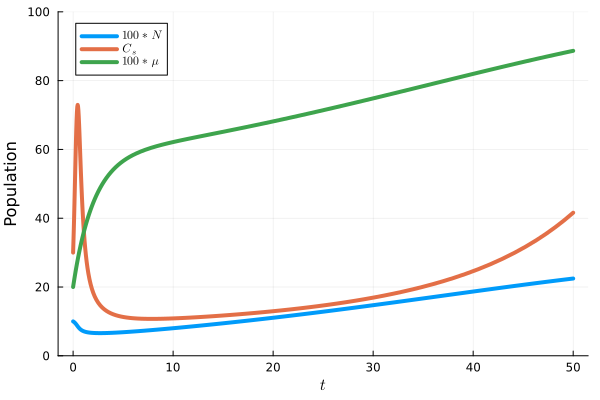

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=0.25, σ_0=0.8
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, exC, μ = z
    Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.75,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.8,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, log10(C0), μ0]

# Time interval
tspan = (0.0, 50.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)




Cs = 10 .^ sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylim=[0, 100]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
   100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

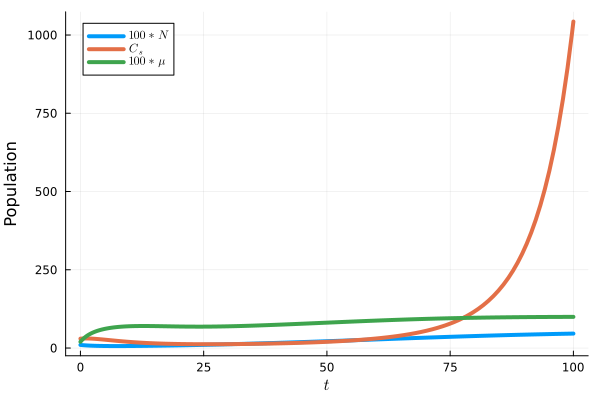

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=0.25, σ_0=0.8
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
    # Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.75,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.8,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, (C0), μ0]

# Time interval
tspan = (0.0, 100.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)




# Cs = 10 .^ sol[2, :]
Cs = sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
   100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

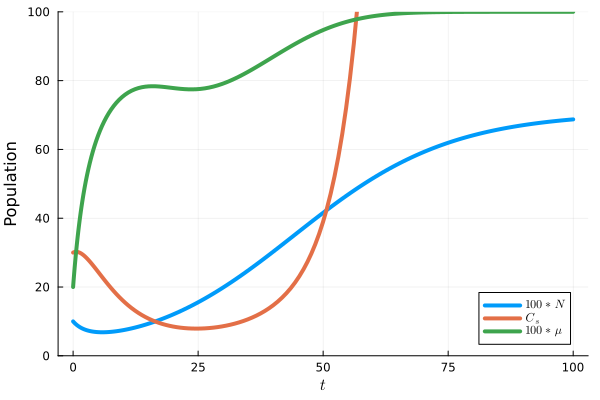

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=0.25, σ_0=0.3
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
    # Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.75,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 100.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)




Cs =  sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylim=[0, 100]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
   100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

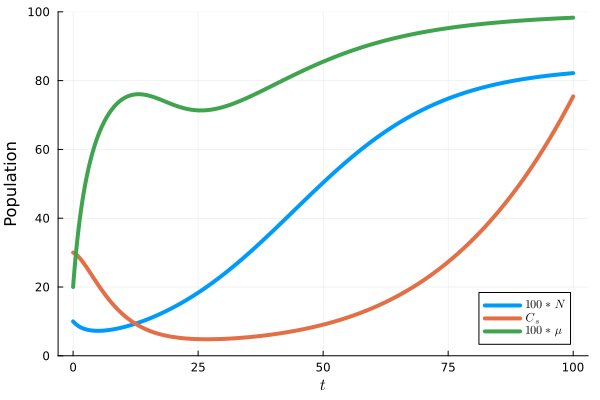

In [9]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
    # Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 100.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)




Cs =  sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylims=[0,100]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
   100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

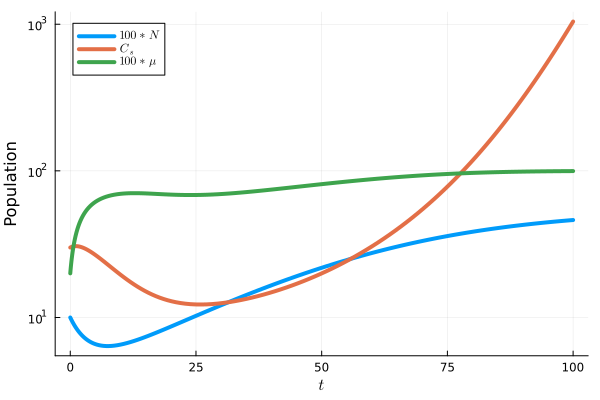

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.25, σ_0=0.8
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
# Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.75,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.8,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, (C0), μ0]

# Time interval
tspan = (0.0, 100.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

solve(
        prob,
Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2,
    yscale = :log10
)




# Cs = 10 .^ sol[2, :]
Cs = sol[2, :]

plot(
    sol.t,
100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4,
    yscale = :log10
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

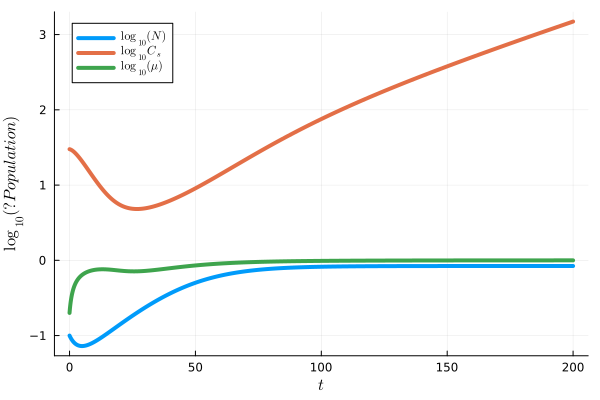

In [6]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
    # Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, (C0), μ0]

# Time interval
tspan = (0.0, 200.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

# ---------------------------
# Plot N (log10 of N)
# ---------------------------

p1 = plot(
    sol.t,
    log10.(sol[1, :]),
    xlabel = L"t",
    ylabel = L"\log_{10} N(t)",
    label = L"\log_{10} N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    log10.(sol[1, :]),
    label = L"\log_{10}( N)",
    xlabel = L"t",
    ylabel = L"\log_{10}(\text{Population})",
    lw = 4
)

plot!(
    sol.t,
    log10.(Cs),
    label = L"\log_{10} C_s",
    lw = 4
)

plot!(
    sol.t,
    log10.(sol[3, :]),
    label = L"\log_{10}( \mu)",
    lw = 4
)

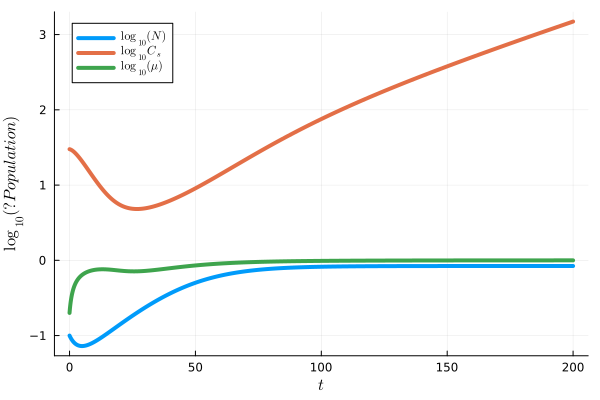

In [7]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=0.7, σ_0=0.8
# ---------------------------


function simul(z, p,t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z
    # Cs = 10^exC

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
     r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

# Since the model uses exC = log10(Cs)
u0 = [N0, (C0), μ0]

# Time interval
tspan = (0.0, 200.0)


# Solve
function solve_traj(u0, p, tspan)

    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# Plot N
# ---------------------------

# ---------------------------
# Plot N (log10 of N)
# ---------------------------

p1 = plot(
    sol.t,
    log10.(sol[1, :]),
    xlabel = L"t",
    ylabel = L"\log_{10} N(t)",
    label = L"\log_{10} N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    log10.(sol[1, :]),
    label = L"\log_{10}( N)",
    xlabel = L"t",
    ylabel = L"\log_{10}(\text{Population})",
    lw = 4
)

plot!(
    sol.t,
    log10.(Cs),
    label = L"\log_{10} C_s",
    lw = 4
)

plot!(
    sol.t,
    log10.(sol[3, :]),
    label = L"\log_{10}( \mu)",
    lw = 4
)

N_0 = 5.349023865095055


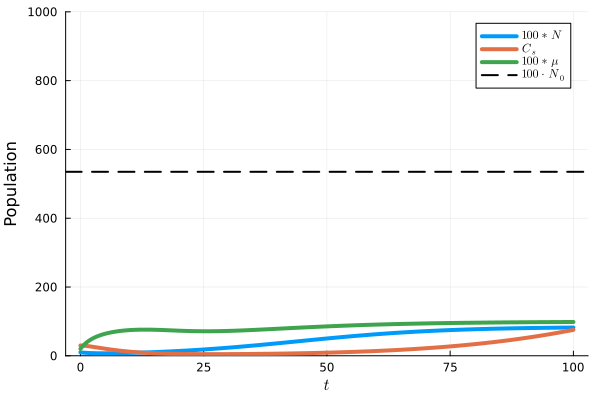

In [7]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p, t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 100.0)


# Solve
function solve_traj(u0, p, tspan)
    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# N_0 = (σ1 δN/r - βδ) + sqrt( (σ1 δN/r - βδ)^2 + 4 βr (1 + δN σ0/r) )
# ---------------------------

function compute_N0(p)
    (; r, δN, βr, βδ, σ0, σ1) = p
    A = σ1*δN/r - βδ
    (A + sqrt(A^2 + 4*βr*(1 + δN*σ0/r)))/(2*βr)
end

N0_val = compute_N0(par_tm)
println("N_0 = ", N0_val)


# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylims=[0,1000]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
    100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

hline!(
    [100*N0_val],
    label = L"100 \cdot N_0",
    lw = 2,
    ls = :dash,
    color = :black
)

N_0 = 0.840698653811067


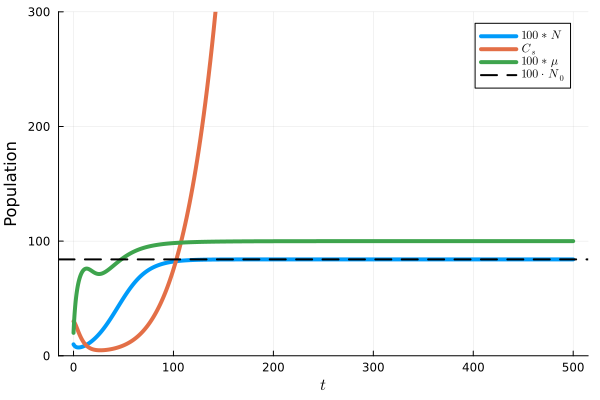

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p, t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end


# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 500.0)


# Solve
function solve_traj(u0, p, tspan)
    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# N_0 = (σ1 δN/r - βδ) + sqrt( (σ1 δN/r - βδ)^2 + 4 βr (1 + δN σ0/r) )
# ---------------------------

function compute_N0(p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    A = -(ΩT-Ω-δC-rC-σ1*δN/r)
    (A - sqrt(A^2 -4*(rC-ΩT)*(δC +Ω-δN*σ0/r)))/(2*(rC-ΩT))
end

N0_val = compute_N0(par_tm)
println("N_0 = ", N0_val)


function comute_lambda_C(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    return (rC-βr)*N0_val-βδ-δC
end

function comute_lambda_μ(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    q= r*(N0_val-1)/δN

    return (σ0+σ1*N0_val/q)+(ΩT- βr)*N0_val +Ω-βδ
end
# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylims=[0,300]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
    100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

hline!(
    [100*N0_val],
    label = L"100 \cdot N_0",
    lw = 2,
    ls = :dash,
    color = :black
)

N_0 = 0.840698653811067
λ (numerical fit)      = 0.026579874452589834
λ (from ρ_C condition) = 0.02564466077074876
λ (from μ_C condition) = 0.025644660770747896
U_C (from fit, exp(b)) = 6.794351775543601


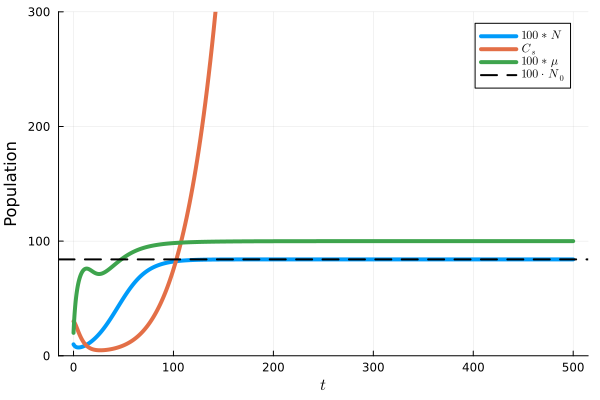

In [ ]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p, t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end

sol = solve_traj(u0, par_tm, tspan)

Ns  = sol[1, :]
Cs  = sol[2, :]
μs  = sol[3, :]
# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 500.0)


# Solve
function solve_traj(u0, p, tspan)
    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)


# ---------------------------
# N_0 = (σ1 δN/r - βδ) + sqrt( (σ1 δN/r - βδ)^2 + 4 βr (1 + δN σ0/r) )
# ---------------------------

function compute_N0(p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    A = -(ΩT-Ω-δC-rC-σ1*δN/r)
    (A - sqrt(A^2 -4*(rC-ΩT)*(δC +Ω-δN*σ0/r)))/(2*(rC-ΩT))
end

N0_val = compute_N0(par_tm)
println("N_0 = ", N0_val)


function comute_lambda_C(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    return (rC-βr)*N0_val-βδ-δC
end

function comute_lambda_μ(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    q= r*(N0_val-1)/δN

    return ((σ0+σ1*N0_val)/q)+(ΩT- βr)*N0_val +Ω-βδ
end
# ---------------------------
# λ validation
# ---------------------------

idx = findall(t -> 100 < t < 400, sol.t)   # tune this window to region P1

tt   = sol.t[idx]
logC = log.(Cs[idx])

X = hcat(tt, ones(length(tt)))
λ_num, b_num = X \ logC

λ_C = comute_lambda_C(N0_val, par_tm)
λ_μ = comute_lambda_μ(N0_val, par_tm)

println("λ (numerical fit)      = ", λ_num)
println("λ (from ρ_C condition) = ", λ_C)
println("λ (from μ_C condition) = ", λ_μ)
println("U_C (from fit, exp(b)) = ", exp(b_num))

dlogC = diff(log.(Cs)) ./ diff(sol.t)

plot(sol.t[2:end], dlogC,
     xlabel=L"t", ylabel=L"d\log C/dt",
     label="numerical", lw=2)
hline!([λ_C], ls=:dash, lw=2, label=L"\lambda\ \mathrm{(analytic)}")

# ---------------------------
# 1-μ and N0-N vs t (log scale)
# ---------------------------

oneMinusMu = 1 .- μs
N0minusN   = N0_val .- Ns

plot(sol.t, abs.(oneMinusMu), yscale=:log10,
     xlabel=L"t", ylabel="magnitude",
     label=L"1-\mu(t)", lw=2)
plot!(sol.t, abs.(N0minusN), yscale=:log10, label=L"N_0-N(t)", lw=2)

# ---------------------------
# 1-μ and N0-N vs C (log-log): test ~1/C scaling
# ---------------------------

plot(Cs, abs.(oneMinusMu), xscale=:log10, yscale=:log10,
     xlabel=L"C", ylabel="magnitude",
     label=L"1-\mu", lw=2)
plot!(Cs, abs.(N0minusN), xscale=:log10, yscale=:log10, label=L"N_0-N", lw=2)

Cref = range(minimum(Cs), maximum(Cs), length=200)
plot!(Cref, abs(oneMinusMu[end])*Cs[end]./Cref, ls=:dash, label=L"\sim 1/C")

# ---------------------------
# local log-log slope: should → -1 if truly ~1/C
# ---------------------------

function local_loglog_slope(x, y)
    lx, ly = log.(x), log.(abs.(y))
    diff(ly) ./ diff(lx)
end

slope_mu = local_loglog_slope(Cs, oneMinusMu)
slope_N  = local_loglog_slope(Cs, N0minusN)

plot(Cs[2:end], slope_mu, xscale=:log10,
     xlabel=L"C", ylabel="local slope",
     label=L"1-\mu", lw=2)
plot!(Cs[2:end], slope_N, label=L"N_0-N", lw=2)
hline!([-1], ls=:dash, color=:black, label="slope = -1")
# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylims=[0,300]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
    100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

hline!(
    [100*N0_val],
    label = L"100 \cdot N_0",
    lw = 2,
    ls = :dash,
    color = :black
)

N_0 = 0.840698653811067
λ (numerical fit)      = 0.026579874452589834
λ (from ρ_C condition) = 0.02564466077074876
λ (from μ_C condition) = 0.025644660770747896
U_C (from fit, exp(b)) = 6.794351775543601


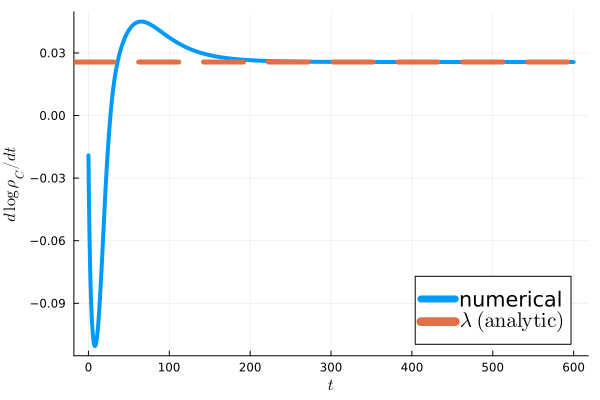

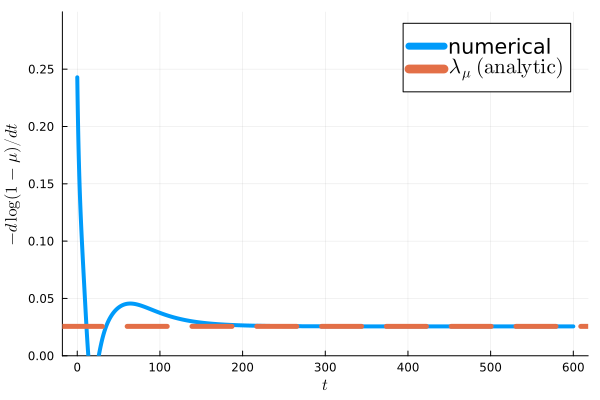

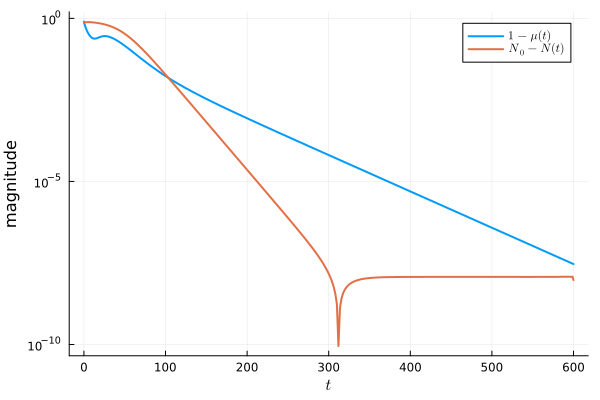

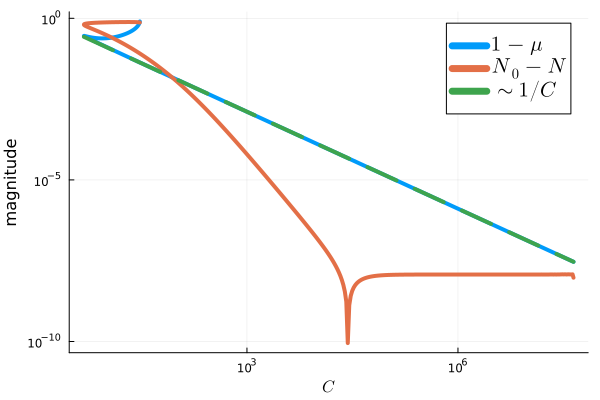

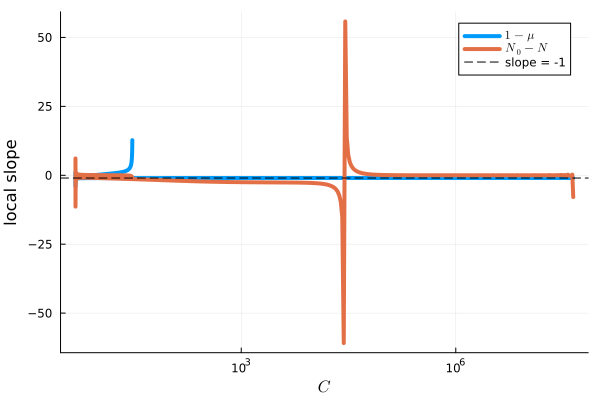

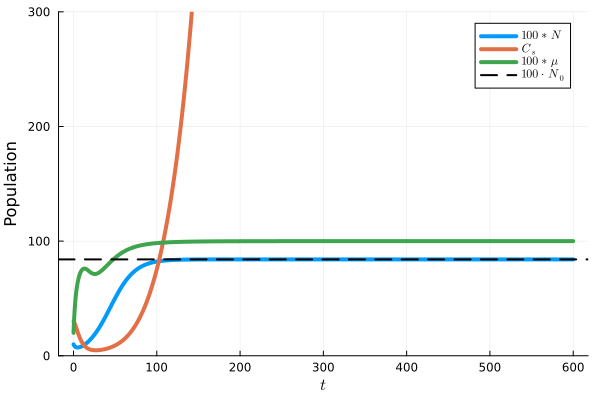

In [12]:
using DifferentialEquations
using Plots
using LinearAlgebra
using LaTeXStrings


# ---------------------------
# Plot  α_1=-0.7, σ_0=0.3
# ---------------------------


function simul(z, p, t)
    (; r, rC, δC, δN, Ω, ΩT, βr, βδ, σ0, σ1) = p

    N, Cs, μ = z

    [
        r*N*(1 - N) - δN*(1-μ)*Cs*N,

        σ0 + σ1*N + rC*Cs*N -
        βr*Cs*μ*N - βδ*μ*Cs - δC*Cs,

        (ΩT*N + Ω)*(1-μ) -
        βr*μ*N*(1-μ) -
        βδ*μ*(1-μ) -
        (μ/Cs)*(σ0 + σ1*N)
    ]
end

# Parameters
par_tm = (
    r   = 0.08078290935711611,
    rC  = 0.3,
    δC  = 0.024386186139200513,
    δN  = 0.01,
    Ω   = 0.18381041120330566,
    ΩT  = 1.0,
    βr  = 0.021848896684677162,
    βδ  = 0.18381041120330566,
    σ0  = 0.3,
    σ1  = 0.8626645475366396
)


# Initial conditions
N0 = 0.1
C0 = 30.0
μ0 = 0.2

u0 = [N0, C0, μ0]

# Time interval
tspan = (0.0, 600.0)


# Solve
function solve_traj(u0, p, tspan)
    prob = ODEProblem(simul, u0, tspan, p)

    solve(
        prob,
        Rodas5P();
        abstol = 1e-9,
        reltol = 1e-7,
        maxiters = Int(1e7)
    )
end


sol = solve_traj(u0, par_tm, tspan)



Ns  = sol[1, :]
Cs  = sol[2, :]
μs  = sol[3, :]
# ---------------------------
# N_0 = (σ1 δN/r - βδ) + sqrt( (σ1 δN/r - βδ)^2 + 4 βr (1 + δN σ0/r) )
# ---------------------------

function compute_N0(p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    A = -(ΩT-Ω-δC-rC-σ1*δN/r)
    (A - sqrt(A^2 -4*(rC-ΩT)*(δC +Ω-δN*σ0/r)))/(2*(rC-ΩT))
end

N0_val = compute_N0(par_tm)
println("N_0 = ", N0_val)


function comute_lambda_C(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    return (rC-βr)*N0_val-βδ-δC
end

function comute_lambda_μ(N0_val, p)
    (; rC,r,δC, ΩT, Ω, δN, βr, βδ, σ0, σ1) = p
    q= r*(N0_val-1)/δN

    return ((σ0+σ1*N0_val)/q)+(ΩT- βr)*N0_val +Ω-βδ
end

idx = findall(t -> 100 < t < 400, sol.t) 

tt   = sol.t[idx]
logC = log.(Cs[idx])

X = hcat(tt, ones(length(tt)))
λ_num, b_num = X \ logC

λ_C = comute_lambda_C(N0_val, par_tm)
λ_μ = comute_lambda_μ(N0_val, par_tm)

println("λ (numerical fit)      = ", λ_num)
println("λ (from ρ_C condition) = ", λ_C)
println("λ (from μ_C condition) = ", λ_μ)
println("U_C (from fit, exp(b)) = ", exp(b_num))

# ---------------------------
# λ validation plot from \rho_C
# ---------------------------

dlogC = diff(log.(Cs)) ./ diff(sol.t)

p_lambda = plot(sol.t[2:end], dlogC,
     xlabel=L"t", ylabel=L"d\log \rho_C/dt",
     label="numerical", lw=4, legendfontsize=14)
hline!(p_lambda, [λ_C], ls=:dash, lw=5, label=L"\lambda\ \mathrm{(analytic)}")
display(p_lambda)

# ---------------------------
# λ validation plot from \mu_C
# ---------------------------
dlog1mu = -diff(log.(1 .- μs)) ./ diff(sol.t)

p_lambda_mu = plot(
    sol.t[2:end],
    dlog1mu,
    xlabel=L"t",
    ylabel=L"-d\log(1-\mu)/dt",
    label="numerical",
    lw=4,
    ylim=[0, 0.3], legendfontsize=14
)

hline!(
    p_lambda_mu,
    [λ_μ],
    ls=:dash,
    lw=5,
    label=L"\lambda_\mu\ \mathrm{(analytic)}"
)

display(p_lambda_mu)
# ---------------------------
# 1-μ and N0-N vs t (log scale)
# ---------------------------

oneMinusMu = 1 .- μs
N0minusN   = N0_val .- Ns

p_vs_t = plot(sol.t, abs.(oneMinusMu), yscale=:log10,
     xlabel=L"t", ylabel="magnitude",
     label=L"1-\mu(t)", lw=2)
plot!(p_vs_t, sol.t, abs.(N0minusN), label=L"N_0-N(t)", lw=2)
display(p_vs_t)

# ---------------------------
# 1-μ and N0-N vs C (log-log): test ~1/C scaling
# ---------------------------

p_vs_C = plot(Cs, abs.(oneMinusMu), xscale=:log10, yscale=:log10,
     xlabel=L"C", ylabel="magnitude",
     label=L"1-\mu", lw=4)
plot!(p_vs_C, Cs, abs.(N0minusN), label=L"N_0-N", lw=4)

Cref = range(minimum(Cs), maximum(Cs), length=200)
plot!(p_vs_C, Cref, abs(oneMinusMu[end])*Cs[end]./Cref, ls=:dash, label=L"\sim 1/C", lw=4, legendfontsize=14)
display(p_vs_C)

# ---------------------------
# local log-log slope: should → -1 if truly ~1/C
# ---------------------------

function local_loglog_slope(x, y)
    lx, ly = log.(x), log.(abs.(y))
    diff(ly) ./ diff(lx)
end

slope_mu = local_loglog_slope(Cs, oneMinusMu)
slope_N  = local_loglog_slope(Cs, N0minusN)

p_slope = plot(Cs[2:end], slope_mu, xscale=:log10,
     xlabel=L"C", ylabel="local slope",
     label=L"1-\mu", lw=4)
plot!(p_slope, Cs[2:end], slope_N, label=L"N_0-N", lw=4)
hline!(p_slope, [-1], ls=:dash, color=:black, label="slope = -1")
display(p_slope)
# ---------------------------
# Plot N
# ---------------------------

p1 = plot(
    sol.t,
    sol[1, :],
    xlabel = L"t",
    ylabel = L"N(t)",
    label = L"N",
    lw = 2
)


Cs = sol[2, :]

plot(
    sol.t,
    100*sol[1, :],
    label = L"100 *N",
    xlabel = L"t",
    ylabel = "Population",
    lw = 4, ylims=[0,300]
)

plot!(
    sol.t,
    Cs,
    label = L"C_s",
    lw = 4
)

plot!(
    sol.t,
    100*sol[3, :],
    label = L"100 *\mu",
    lw = 4
)

hline!(
    [100*N0_val],
    label = L"100 \cdot N_0",
    lw = 2,
    ls = :dash,
    color = :black
)